In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("ggplot")

In [15]:
df = pd.read_csv("data/raw/retail_sales.csv")

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [16]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      str    
 1   store_id  str    
 2   item_id   str    
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 385.9 MB


date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["date"] = pd.to_datetime(df["date"])

In [19]:
df = df.set_index("date")

df.head()

,store_id,item_id,sales,price,promo,weekday,month
date,,,,,,,
2019-01-01,store_1,item_1,41,21.30,0,1,1
2019-01-02,store_1,item_1,53,21.30,0,2,1
2019-01-03,store_1,item_1,39,21.30,0,3,1
2019-01-04,store_1,item_1,35,21.30,0,4,1
2019-01-05,store_1,item_1,51,17.04,1,5,1


In [20]:
full_dates = pd.date_range(df.index.min(), df.index.max())

missing_dates = full_dates.difference(df.index.unique())

print("Missing Dates:", len(missing_dates))

Missing Dates: 0


In [34]:
product_df = df[
    (df["store_id"] == "store_1") &
    (df["item_id"] == "item_1")
]

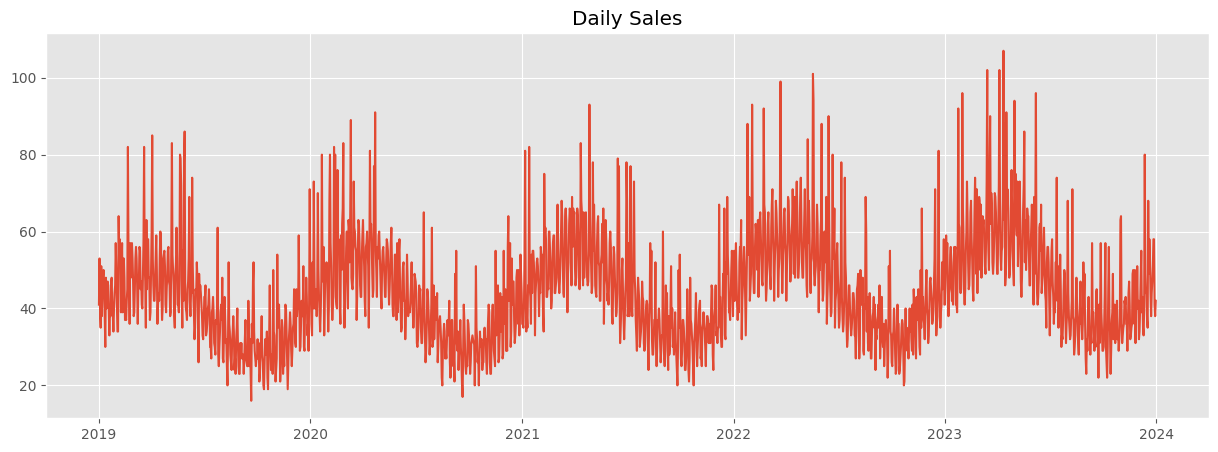

In [35]:
plt.figure(figsize=(15,5))

plt.plot(product_df.index, product_df["sales"])

plt.title("Daily Sales")

plt.show()

In [36]:
monthly_sales = product_df["sales"].resample("ME").sum()

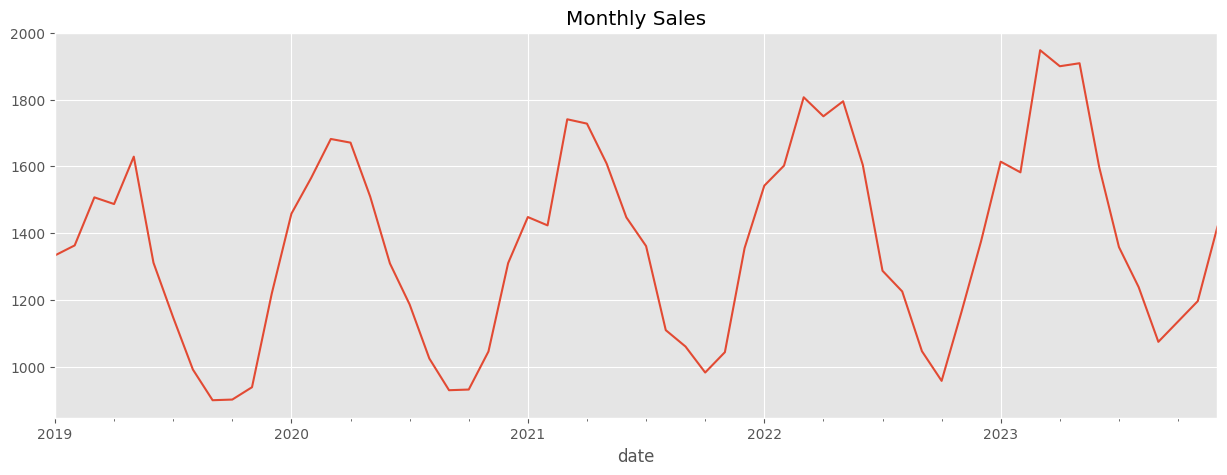

In [37]:
monthly_sales.plot(figsize=(15,5))
plt.title("Monthly Sales")
plt.show()